In [1]:
###Select folders to analyze
calibration_path = 'D:/Augusto/Images/NSPARC/20241011-NSPARC/mEGFP-KDM5A-mCherry/analysis_20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry' #avoid writing a dash / at the end
calibration_genotype = 'U2OSlive-mEGFP-KDM5A-mCherry'

#Figure outputs
output_path = "D:/Augusto/PythonCode/Figure1/"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import csv
from scipy.stats import linregress
import matplotlib.ticker as ticker
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

In [3]:
##Functions to read cell calibration datafiles and generate data structures

#date	dataset	z-slice	cell_Id	x	y	raw_exp_mEGFP	raw_exp_mCherry	cell_area	
#background_mEGFP	background_mCherry

def read_cell_calibration_datafiles(calibration_path, calibration_genotype):
    
    dataset_date = calibration_path.split('/')[-2]
    datafolder = os.path.join(calibration_path)
    os.chdir(datafolder)
    print(os.getcwd())

    files_in_folder = os.listdir()

    calibration_data_cells = []
    calibration_data_cells.append(["date","dataset","z-slice","cell_Id",
                           "x", "y", "raw_exp_mEGFP", "raw_exp_mCherry", "cell_area", 
                           "background_mEGFP", "background_mCherry"])
    
    for element in files_in_folder:
        if dataset_date in element and calibration_genotype in element and element.endswith("_cells.txt"):
            file_to_open = element
            print("file to open:", file_to_open)

            with open(file_to_open, "r") as file:
                reader = csv.reader(file, delimiter="\t")
                next(reader) # Skip the first row
                #Loop through the rows in the file and append the data
                for row in reader:
                    calibration_data_cells.append([row[0], row[1], row[2], row[3], row[4], row[5], row[6],
                                         row[7], row[8], row[9], row[10]])

    return(calibration_data_cells)

calibration_data_cells = read_cell_calibration_datafiles(calibration_path, calibration_genotype)

D:\Augusto\Images\NSPARC\20241011-NSPARC\mEGFP-KDM5A-mCherry\analysis_20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry
file to open: 20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry_0000_cells.txt
file to open: 20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry_0001_cells.txt
file to open: 20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry_0002_cells.txt
file to open: 20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry_0003_cells.txt
file to open: 20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry_0004_cells.txt
file to open: 20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry_0005_cells.txt
file to open: 20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry_0006_cells.txt
file to open: 20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry_0007_cells.txt
file to open: 20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry_0008_cells.txt
file to open: 20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry_0009_cells.txt
file to open: 20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry_0010_cells.txt
file to open: 20241011-NSPARC_U2OSlive-mEGFP-KDM5A-mCherry_0011_cells.t

In [4]:
##Functions to read cells and condensate datafiles and generate data structures

# headers_cells = ("date" + "\t" + "dataset" + "\t" + "z-slice" + "\t" + "cell_Id"
#            "\t" + "x" + "\t" + "y" + "\t" + "raw_exp" + "\t" + "cell_area" + "\t" + "background" +
#            "\t" + "nuc_intensity" + "\t" + "nuc_area" + "\n")

def read_cells_datafiles(path, genotype):
    
    dataset_date = path.split('/')[-1]
    datafolder = os.path.join(path)
    os.chdir(datafolder)
    print(os.getcwd())

    files_in_folder = os.listdir()

    cells_data_all = []
    cells_data_all.append(["date","dataset","z-slice","cell_Id",
                           "x", "y", "raw_exp", "cell_area", "background", 
                           "nuc_intensity", "nuc_area"])
    
    for element in files_in_folder:
        if dataset_date in element and genotype in element and element.endswith("_cells.txt"):
            file_to_open = element
            print("file to open:", file_to_open)

            with open(file_to_open, "r") as file:
                reader = csv.reader(file, delimiter="\t")
                next(reader) # Skip the first row
                #Loop through the rows in the file and append the data
                for row in reader:
                    cells_data_all.append([row[0], row[1], row[2], row[3], row[4], row[5], row[6],
                                         row[7], row[8], row[9], row[10]])

    return(cells_data_all)

# headers_condensates = ("date" + "\t" + "dataset" + "\t" + "cell_Id" +
#            "\t" + "condensateID" + "\t" + "x" + "\t" + "y" + 
#            "\t" + "raw_mass" + "\t" + "size" + "\t" + "ecc" + "\n")

def read_condensates_datafiles(path, genotype):
    
    dataset_date = path.split('/')[-1]
    datafolder = os.path.join(path)
    os.chdir(datafolder)
    print(os.getcwd())

    files_in_folder = os.listdir()

    condensates_data_all = []
    condensates_data_all.append(["date","dataset","cell_Id","condensateID",
                          "x", "y", "raw_mass","size", "ecc"])
    
    for element in files_in_folder:
        if dataset_date in element and genotype in element and element.endswith("_condensates.txt"):
            file_to_open = element
            print("file to open:", file_to_open)

            with open(file_to_open, "r") as file:
                reader = csv.reader(file, delimiter="\t")
                next(reader) # Skip the first row
                #Loop through the rows in the file and append the data
                for row in reader:
                    condensates_data_all.append([row[0], row[1], row[2], row[3], row[4], row[5], row[6],
                                         row[7], row[8]])

    return(condensates_data_all)



In [5]:
##Generate variables with cell and condensate data for further plotting

def calibration_cell_analysis(calibration_data_cells):

    # headers_cells = ("date","dataset","z-slice","cell_Id",
                           #"x", "y", "raw_exp_mEGFP", "raw_exp_mCherry", "cell_area", 
                           #"background_mEGFP", "background_mCherry")        
    
    mEGFP_cell_values = []
    mCherry_cell_values = []
    for row_cell in calibration_data_cells[1:]:
        
        mEGFP_cell_v = float(row_cell[6]) / float(row_cell[8])
        mCherry_cell_v =  float(row_cell[7]) / float(row_cell[8])

        if mEGFP_cell_v < 3800 and mCherry_cell_v < 3800: #4096 counts is the saturation point for NSPARC
        
            mEGFP_cell_values.append(mEGFP_cell_v)
            mCherry_cell_values.append(mCherry_cell_v)
        
    mEGFP_cell_values = np.array(mEGFP_cell_values, dtype = float)
    mCherry_cell_values = np.array(mCherry_cell_values, dtype = float)
        
    return(mEGFP_cell_values, mCherry_cell_values)
                

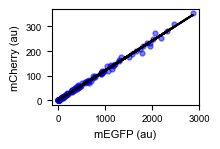

n = 123


In [19]:
mEGFP_cell_values, mCherry_cell_values = calibration_cell_analysis(calibration_data_cells)

# Perform linear regression and retrieve regression line
slope, intercept, r_value, p_value, std_err = linregress(mEGFP_cell_values, mCherry_cell_values)

regression_line_mEGFPmCherry = slope * mEGFP_cell_values

# Plot scatter and regression line
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.6))

ax.scatter(mEGFP_cell_values, mCherry_cell_values, color='blue', label='cells', marker = '.',
         s = 50, alpha = 0.5)
ax.plot(mEGFP_cell_values, regression_line_mEGFPmCherry, color='black', label=f'Regression line y={slope:.2f}x')#+{intercept:.2f})')

ax.set_xlabel('mEGFP (au)', fontsize=8, fontname="Arial")
ax.set_ylabel('mCherry (au)', fontsize=8, fontname="Arial")

ax.set_yticks([0, 100, 200, 300])

ax.tick_params(axis='x', labelsize=7)
ax.tick_params(axis='y', labelsize=7)

#plt.legend()
#plt.grid()
fig.tight_layout()
plt.show()

# Save as PNG, 300 dpi is publication quality
image_file_name = output_path + "mEGFP_mCherry_calibration.png"
fig.savefig(image_file_name, bbox_inches='tight', pad_inches=0.1, dpi=300, format="png")
plt.close(fig)

print("n =", len(mEGFP_cell_values))




In [7]:
def mCherry_mEGFP_conversion(mCherry_list, slope):
    
    mCherry2mEGFP_list = [(y)/slope for y in mCherry_list]
        
    return(mCherry2mEGFP_list)

In [8]:
#Read calibration files

def read_concentration_calibration_files(concentration_calibration_path, protein):
    
    datafolder = os.path.join(concentration_calibration_path)
    os.chdir(datafolder)
    print(os.getcwd())

    files_in_folder = os.listdir()
    print(files_in_folder)
    
    concentration_calibration_data = []
    concentration_calibration_data.append(["date","protein", "replica", "concentration","dataset","meanin", "meanout"])
    
    for element in files_in_folder:
        if protein in element and element.endswith("_NSPARCcalibration_output.txt"):
            file_to_open = element
            print("file to open:", file_to_open)
            
            with open(file_to_open, "r") as file:
                reader = csv.reader(file, delimiter="\t")
                next(reader) # Skip the first row
                #Loop through the rows in the file and append the data
                for row in reader:
                    concentration_calibration_data.append([row[0], row[1], row[2], row[3], row[4], row[6], row[8]])
    
    return(concentration_calibration_data)


def concentration_calibration_points(concentration_calibration_data):

    concentration_calibration_values = []
    for row_concentration_calibration in concentration_calibration_data[1:]:
    
        adjusted_brightness = float(row_concentration_calibration[5]) - float(row_concentration_calibration[6])
        concentration_calibration_values.append((int(row_concentration_calibration[3]), adjusted_brightness))
        print((int(row_concentration_calibration[3]), float(row_concentration_calibration[5])))

    #background_0nM = next(item[1] for item in calibration_values if item[0] == 0)
    
    return(concentration_calibration_values)

D:\Augusto\Images\NSPARC\20241202-NSPARC
['20241202-NSPARC-EGFP_NSPARCcalibration_output.txt', 'EGFP-brep1-0nM_0000.nd2', 'EGFP-brep1-0nM_0001.nd2', 'EGFP-brep1-0nM_0002.nd2', 'EGFP-brep1-100nM_0000.nd2', 'EGFP-brep1-100nM_0001.nd2', 'EGFP-brep1-100nM_0002.nd2', 'EGFP-brep1-200nM_0000.nd2', 'EGFP-brep1-200nM_0001.nd2', 'EGFP-brep1-200nM_0002.nd2', 'EGFP-brep1-50nM_0000.nd2', 'EGFP-brep1-50nM_0001.nd2', 'EGFP-brep1-50nM_0002.nd2', 'EGFP-brep2-0nM_0000.nd2', 'EGFP-brep2-0nM_0001.nd2', 'EGFP-brep2-0nM_0002.nd2', 'EGFP-brep2-100nM_0000.nd2', 'EGFP-brep2-100nM_0001.nd2', 'EGFP-brep2-100nM_0002.nd2', 'EGFP-brep2-200nM_0000.nd2', 'EGFP-brep2-200nM_0001.nd2', 'EGFP-brep2-200nM_0002.nd2', 'EGFP-brep2-50nM_0000.nd2', 'EGFP-brep2-50nM_0001.nd2', 'EGFP-brep2-50nM_0002.nd2', 'Settings.txt']
file to open: 20241202-NSPARC-EGFP_NSPARCcalibration_output.txt
(200, 1.8267805555555556)
(200, 1.8355833333333333)
(200, 1.8269916666666666)
(200, 1.6247277777777778)
(200, 1.5791527777777778)
(200, 1.629630555

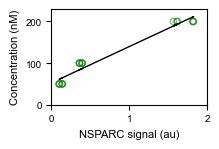

In [20]:
#Intercept of calibration line was adjusted to 0

concentration_calibration_path = 'D:/Augusto/Images/NSPARC/20241202-NSPARC/'
protein = 'EGFP'

concentration_calibration_data_NSPARC_mEGFP = read_concentration_calibration_files(concentration_calibration_path, protein)
mEGFP_values = concentration_calibration_points(concentration_calibration_data_NSPARC_mEGFP)

# Performing linear regressions
# Excluding lowest values
y_mEGFP_concentration = np.array([item[0] for item in mEGFP_values if item[0] >= 50])
x_mEGFP_fluorescence = np.array([item[1] for item in mEGFP_values if item[0] >= 50])

uncertain_intensity_mEGFP = np.mean(np.array([item[1] for item in mEGFP_values if item[0] == 50]))
print("x_mEGFP_fluorescence", x_mEGFP_fluorescence)
print("y_mEGFP_concentration", y_mEGFP_concentration)
print("uncertain_intensity_mEGFP", uncertain_intensity_mEGFP)

slope_concentration_mEGFP, intercept_concentration_mEGFP, r_value_concentration_mEGFP, p_value_concentration_mEGFP, std_err_concentration_mEGFP = linregress(x_mEGFP_fluorescence, y_mEGFP_concentration)
#intercept_concentration_mEGFP = 0

# Regression line equation
equation_mEGFP = f"y = {slope_concentration_mEGFP:.2f}x + {intercept_concentration_mEGFP:.2f}"

print(equation_mEGFP)


######
######
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.6))

# Plotting the data points and regression line
ax.scatter(x_mEGFP_fluorescence, y_mEGFP_concentration, facecolor='none',  edgecolor='green',
          marker = 'o', s = 20, alpha = 0.5)

ax.plot(x_mEGFP_fluorescence, slope_concentration_mEGFP * x_mEGFP_fluorescence + intercept_concentration_mEGFP, linewidth = 1, color='black', label = equation_mEGFP)

# Adding labels and title
ax.set_xlabel('NSPARC signal (au)', fontsize=8, fontname="Arial")
ax.set_ylabel('Concentration (nM)', fontsize=8, fontname="Arial")
#plt.title('EGFP\ncalibration of molarity and fluorescence')
ax.set_ylim(0, 230)
ax.set_xlim(0, 2)
ax.set_xticks([0, 1, 2])

ax.tick_params(axis='x', labelsize=7)
ax.tick_params(axis='y', labelsize=7)

# Show the plot
#plt.grid()
fig.tight_layout()
plt.show()

# Save as PNG, 300 dpi is publication quality
image_file_name = output_path + "mEGFP_calibration_molarity.png"
fig.savefig(image_file_name, bbox_inches='tight', pad_inches=0.1, dpi=300, format="png")
plt.close(fig)


In [10]:
##Generate variables with cell and condensate data for further plotting

#data_analysis(data_cells, data_condensates)
#return()

def data_analysis(data_cells, data_condensates):

    # headers_cells = ("date" + "\t" + "dataset" + "\t" + "z-slice" + "\t" + "cell_Id"
    #            "\t" + "x" + "\t" + "y" + "\t" + "raw_exp" + "\t" + "cell_area" + "\t" + "background" +
    #            "\t" + "nuc_intensity" + "\t" + "nuc_area" + "\n")

    # headers_condensates = ("date" + "\t" + "dataset" + "\t" + "cell_Id" +
    #            "\t" + "condensateID" + "\t" + "x" + "\t" + "y" + 
    #            "\t" + "raw_mass" + "\t" + "size" + "\t" + "ecc" +"\n")
    
    max_condensate_size = 2000 #maximum condensate size 
    min_condensate_size = 1 #minimum condensate size (0)
    
    dataset_all = []
    cell_ID_all = []
    
    mean_cell_intensity_all = [] #x-axis
    mean_nucleoplasm_intensity_all = [] #y-axis 3 

    density_condensates_in_cell_all = [] #y-axis 1
    fraction_of_cell_signal_in_condensates_all = [] #y-axis 2
    fraction_of_area_in_condensates_all = []
    
    mean_intensity_of_condensates_in_cell_all = [] 
    mean_size_of_condensates_in_cell_all = []
    
    
    for row_cell in data_cells[1:]:
        
        #print(row_cell)
        dataset_all.append(row_cell[1])
        #print(row_cell[1])
        cell_ID_all.append(row_cell[3])

        #Cell stats
        background = float(row_cell[8]) #background
        mean_cell_intensity = float(row_cell[6]) / float(row_cell[7]) #- background #background substracted
        mean_nucleoplasm_intensity = float(row_cell[9]) / float(row_cell[10]) #- background #background substracted
        
        #Condensate stats for the current cell
        n_condensates_in_cell = 0
        sum_of_condensates_raw_mass = 0
        sum_of_condensates_area = 0
        
        mean_intensity_of_condensates_in_cell = []
        size_of_condensates_in_cell = []

        
        for row_condensate in data_condensates[1:]:
            if row_cell[0] == row_condensate[0] and row_cell[1] == row_condensate[1] and row_cell[3] == row_condensate[2]:

    #             print("\ndate", row_cell[0], row_condensate[0])
    #             print("dataset", row_cell[1], row_condensate[1])
    #             print("cell_Id", row_cell[3], row_condensate[2])
    #             print("condensateID", row_condensate[3])
    
                #Discard large condensates, as they may be nucleolar accumulation of protein
                if float(row_condensate[7]) > max_condensate_size or float(row_condensate[7]) < min_condensate_size:
                    continue

                n_condensates_in_cell = n_condensates_in_cell + 1
                sum_of_condensates_raw_mass = sum_of_condensates_raw_mass + float(row_condensate[6])
                sum_of_condensates_area = sum_of_condensates_area + float(row_condensate[7])
                
                mean_intensity_of_condensates = float(row_condensate[6])/float(row_condensate[7]) #- background #background substracted
                mean_intensity_of_condensates_in_cell.append(mean_intensity_of_condensates)
                
                size_of_condensates_in_cell.append(float(row_condensate[7]))
                
        mean_cell_intensity_all.append(mean_cell_intensity)       

        density_condensates_in_cell = n_condensates_in_cell / float(row_cell[7])
        density_condensates_in_cell_all.append(density_condensates_in_cell) 

        fraction_of_cell_signal_in_condensates = sum_of_condensates_raw_mass / float(row_cell[6])
        fraction_of_cell_signal_in_condensates_all.append(fraction_of_cell_signal_in_condensates)
        
        fraction_of_area_in_condensates = sum_of_condensates_area / float(row_cell[7])
        fraction_of_area_in_condensates_all.append(fraction_of_area_in_condensates)

        mean_nucleoplasm_intensity_all.append(mean_nucleoplasm_intensity)
        
        mean_intensity_of_condensates_in_cell_all.append(np.mean(mean_intensity_of_condensates_in_cell) if len(mean_intensity_of_condensates_in_cell) != 0 else 0)
#         print('mean_intensity_of_condensates_in_cell', mean_intensity_of_condensates_in_cell)
#         print('np.mean(mean_intensity_of_condensates_in_cell)', np.mean(mean_intensity_of_condensates_in_cell))
#         print('mean_intensity_of_condensates_in_cell_all', mean_intensity_of_condensates_in_cell_all)
        
        mean_size_of_condensates_in_cell_all.append(np.mean(size_of_condensates_in_cell) if len(size_of_condensates_in_cell) != 0 else 0)
        
#         if fraction_of_cell_signal_in_condensates > 0.18 and mean_cell_intensity < 30:
#             print('date', row_cell[0])
#             print('dataset', row_cell[1])
#             print('cellID', row_cell[3])
#             print('mean_cell_intensity', mean_cell_intensity)
#             print('sum_of_condensates_raw_mass', sum_of_condensates_raw_mass)
#             print('raw_exp', float(row_cell[6]))
#             print('fraction_of_cell_signal_in_condensates', fraction_of_cell_signal_in_condensates)

        
    return [mean_cell_intensity_all,
            mean_nucleoplasm_intensity_all,
            density_condensates_in_cell_all,
            fraction_of_cell_signal_in_condensates_all,
            fraction_of_area_in_condensates_all,
            mean_intensity_of_condensates_in_cell_all,
            mean_size_of_condensates_in_cell_all,
            dataset_all,
            cell_ID_all]


In [11]:
###Read Nup98-KDM5A-mEGFP data from NSPARC

path_Nup98KDM5A_mEGFP = 'D:/Augusto/Images/NSPARC/20241012-NSPARC/Nup98-KDM5A-mEGFP/analysis_20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP/'
genotype_Nup98KDM5A_mEGFP = 'Nup98-KDM5A-mEGFP'

data_cells_Nup98KDM5A_mEGFP = read_cells_datafiles(path_Nup98KDM5A_mEGFP, genotype_Nup98KDM5A_mEGFP)
data_condensates_Nup98KDM5A_mEGFP = read_condensates_datafiles(path_Nup98KDM5A_mEGFP, genotype_Nup98KDM5A_mEGFP)

analysis_Nup98KDM5A_mEGFP = data_analysis(data_cells_Nup98KDM5A_mEGFP, data_condensates_Nup98KDM5A_mEGFP)

mean_cell_intensity_Nup98KDM5A_mEGFP = analysis_Nup98KDM5A_mEGFP[0]
mean_nucleoplasm_intensity_Nup98KDM5A_mEGFP = analysis_Nup98KDM5A_mEGFP[1]
density_condensates_Nup98KDM5A_mEGFP = analysis_Nup98KDM5A_mEGFP[2]
fraction_of_cell_signal_in_condensates_Nup98KDM5A_mEGFP = analysis_Nup98KDM5A_mEGFP[3]
fraction_of_area_in_condensates_Nup98KDM5A_mEGFP = analysis_Nup98KDM5A_mEGFP[4]
mean_intensity_of_condensates_Nup98KDM5A_mEGFP = analysis_Nup98KDM5A_mEGFP[5]
mean_size_of_condensates_Nup98KDM5A_mEGFP = analysis_Nup98KDM5A_mEGFP[6]

dataset_Nup98KDM5A_mEGFP = analysis_Nup98KDM5A_mEGFP[7]
cell_ID_Nup98KDM5A_mEGFP = analysis_Nup98KDM5A_mEGFP[8]

D:\Augusto\Images\NSPARC\20241012-NSPARC\Nup98-KDM5A-mEGFP\analysis_20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP_0000_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP_0001_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP_0002_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP_0003_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP_0004_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP_0005_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP_0006_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP_0007_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP_0008_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP_0009_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP_0010_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mEGFP_0011_cells.txt
file to open: 20241012-NS

In [12]:
###Read Nup98-KDM5Amut-mEGFP data from NSPARC

path_Nup98KDM5Amut_mEGFP = 'D:/Augusto/Images/NSPARC/20241012-NSPARC/Nup98-KDM5Amut-mEGFP/analysis_20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGFP/'
genotype_Nup98KDM5Amut_mEGFP = 'Nup98-KDM5Amut-mEGFP'

data_cells_Nup98KDM5Amut_mEGFP = read_cells_datafiles(path_Nup98KDM5Amut_mEGFP, genotype_Nup98KDM5Amut_mEGFP)
data_condensates_Nup98KDM5Amut_mEGFP = read_condensates_datafiles(path_Nup98KDM5Amut_mEGFP, genotype_Nup98KDM5Amut_mEGFP)

analysis_Nup98KDM5Amut_mEGFP = data_analysis(data_cells_Nup98KDM5Amut_mEGFP, data_condensates_Nup98KDM5Amut_mEGFP)

mean_cell_intensity_Nup98KDM5Amut_mEGFP = analysis_Nup98KDM5Amut_mEGFP[0]
mean_nucleoplasm_intensity_Nup98KDM5Amut_mEGFP = analysis_Nup98KDM5Amut_mEGFP[1]
density_condensates_Nup98KDM5Amut_mEGFP = analysis_Nup98KDM5Amut_mEGFP[2]
fraction_of_cell_signal_in_condensates_Nup98KDM5Amut_mEGFP = analysis_Nup98KDM5Amut_mEGFP[3]
fraction_of_area_in_condensates_Nup98KDM5Amut_mEGFP = analysis_Nup98KDM5Amut_mEGFP[4]
mean_intensity_of_condensates_Nup98KDM5Amut_mEGFP = analysis_Nup98KDM5Amut_mEGFP[5]
mean_size_of_condensates_Nup98KDM5Amut_mEGFP = analysis_Nup98KDM5Amut_mEGFP[6]

dataset_Nup98KDM5Amut_mEGFP = analysis_Nup98KDM5Amut_mEGFP[7]
cell_ID_Nup98KDM5Amut_mEGFP = analysis_Nup98KDM5Amut_mEGFP[8]

D:\Augusto\Images\NSPARC\20241012-NSPARC\Nup98-KDM5Amut-mEGFP\analysis_20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGFP
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGFP_0000_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGFP_0001_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGFP_0002_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGFP_0003_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGFP_0004_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGFP_0005_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGFP_0006_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGFP_0007_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGFP_0008_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGFP_0009_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGFP_0010_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5Amut-mEGF

In [13]:
###Read Nup98-KDM5A-mCherry data from NSPARC

path_Nup98KDM5A_mCherry = 'D:/Augusto/Images/NSPARC/20241012-NSPARC/Nup98-KDM5A-mCherry/analysis_20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry/'
genotype_Nup98KDM5A_mCherry = 'Nup98-KDM5A-mCherry'

data_cells_Nup98KDM5A_mCherry = read_cells_datafiles(path_Nup98KDM5A_mCherry, genotype_Nup98KDM5A_mCherry)
data_condensates_Nup98KDM5A_mCherry = read_condensates_datafiles(path_Nup98KDM5A_mCherry, genotype_Nup98KDM5A_mCherry)

analysis_Nup98KDM5A_mCherry = data_analysis(data_cells_Nup98KDM5A_mCherry, data_condensates_Nup98KDM5A_mCherry)

mean_cell_intensity_Nup98KDM5A_mCherry = analysis_Nup98KDM5A_mCherry[0]
mean_nucleoplasm_intensity_Nup98KDM5A_mCherry = analysis_Nup98KDM5A_mCherry[1]
density_condensates_Nup98KDM5A_mCherry = analysis_Nup98KDM5A_mCherry[2]
fraction_of_cell_signal_in_condensates_Nup98KDM5A_mCherry = analysis_Nup98KDM5A_mCherry[3]
fraction_of_area_in_condensates_Nup98KDM5A_mCherry = analysis_Nup98KDM5A_mCherry[4]
mean_intensity_of_condensates_Nup98KDM5A_mCherry = analysis_Nup98KDM5A_mCherry[5]
mean_size_of_condensates_Nup98KDM5A_mCherry = analysis_Nup98KDM5A_mCherry[6]

dataset_Nup98KDM5A_mCherry = analysis_Nup98KDM5A_mCherry[7]
cell_ID_Nup98KDM5A_mCherry = analysis_Nup98KDM5A_mCherry[8]

D:\Augusto\Images\NSPARC\20241012-NSPARC\Nup98-KDM5A-mCherry\analysis_20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry_0000_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry_0001_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry_0002_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry_0003_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry_0004_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry_0005_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry_0006_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry_0007_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry_0008_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry_0009_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry_0010_cells.txt
file to open: 20241012-NSPARC_U2OSlive-Nup98-KDM5A-mCherry_0011_cells.t

In [14]:
#Conversion of intensity values to concentration values
#We are not using the intercept for the molarity calculation

#Nup98KDM5A_mEGFP cell concentration

print("uncertain_intensity_mEGFP", uncertain_intensity_mEGFP)

mean_cell_intensity_Nup98KDM5A_mEGFP = np.array(mean_cell_intensity_Nup98KDM5A_mEGFP)
#mean_cell_concentration_Nup98KDM5A_mEGFP = np.where(mean_cell_intensity_Nup98KDM5A_mEGFP > uncertain_intensity_mEGFP, mean_cell_intensity_Nup98KDM5A_mEGFP * slope_concentration_mEGFP + intercept_concentration_mEGFP, 0)

#Nup98KDM5Amut_mEGFP cell concentration
mean_cell_intensity_Nup98KDM5Amut_mEGFP = np.array(mean_cell_intensity_Nup98KDM5Amut_mEGFP)
#mean_cell_concentration_Nup98KDM5Amut_mEGFP = np.where(mean_cell_intensity_Nup98KDM5Amut_mEGFP > uncertain_intensity_mEGFP, mean_cell_intensity_Nup98KDM5Amut_mEGFP * slope_concentration_mEGFP + intercept_concentration_mEGFP, 0)

#Nup98KDM5A_mCherry cell concentration
mean_cell_normalized_Nup98KDM5A_mCherry = mCherry_mEGFP_conversion(mean_cell_intensity_Nup98KDM5A_mCherry, slope)
mean_cell_normalized_Nup98KDM5A_mCherry = np.array(mean_cell_normalized_Nup98KDM5A_mCherry)

#mean_cell_concentration_Nup98KDM5A_mCherry = np.where(mean_cell_normalized_Nup98KDM5A_mCherry > uncertain_intensity_mEGFP, mean_cell_normalized_Nup98KDM5A_mCherry * slope_concentration_mEGFP + intercept_concentration_mEGFP, 0)

#Calculate intensity relative to concentrations
#y = mx + b
#(y - b)m = x

intensity_mEGFP_180nM = (180 - intercept_concentration_mEGFP) / slope_concentration_mEGFP
intensity_mEGFP_500nM = (500 - intercept_concentration_mEGFP) / slope_concentration_mEGFP
intensity_mEGFP_1000nM = (1000 - intercept_concentration_mEGFP) / slope_concentration_mEGFP
intensity_mEGFP_5000nM = (5000 - intercept_concentration_mEGFP) / slope_concentration_mEGFP


print("intensity_mEGFP_100nM", intensity_mEGFP_180nM)
print("intensity_mEGFP_200nM", intensity_mEGFP_500nM)
print("intensity_mEGFP_5000nM", intensity_mEGFP_1000nM)
print("intensity_mEGFP_5000nM", intensity_mEGFP_5000nM)

uncertain_intensity_mEGFP 0.11899583333333334
intensity_mEGFP_100nM 1.459894747598188
intensity_mEGFP_200nM 5.125272497645954
intensity_mEGFP_5000nM 10.852425232095587
intensity_mEGFP_5000nM 56.669647107692654


In [15]:
#Color palettes
#https://colorany.com/color-palettes/colorblind-friendly-color-palettes/

Nup98_KDM5A_mEGFP_color = '#6AB04C'
Nup98_KDM5Amut_mEGFP_color = '#3D5B99'
Nup98_KDM5A_mCherry_color = '#D5006D'

#Labels
#n for each dataset
n_Nup98_KDM5A_mEGFP = len(mean_cell_intensity_Nup98KDM5A_mEGFP)
n_Nup98_KDM5Amut_mEGFP = len(mean_cell_intensity_Nup98KDM5Amut_mEGFP)
n_Nup98_KDM5A_mCherry = len(mean_cell_normalized_Nup98KDM5A_mCherry)

#label
label_Nup98_KDM5A_mEGFP = "Nup98-KDM5A-mEGFP, n = " + str(n_Nup98_KDM5A_mEGFP)
label_Nup98_KDM5Amut_mEGFP = "Nup98-KDM5Amut-mEGFP, n = " + str(n_Nup98_KDM5Amut_mEGFP)
label_Nup98_KDM5A_mCherry = "Nup98-KDM5Amut-mCherry, n = " + str(n_Nup98_KDM5A_mCherry)

#legend handles
legend_handles = [
    plt.Line2D([], [], marker='o', markerfacecolor=Nup98_KDM5A_mEGFP_color, color='None', linestyle='None', label=label_Nup98_KDM5A_mEGFP),
    plt.Line2D([], [], marker='o', markerfacecolor=Nup98_KDM5Amut_mEGFP_color, color='None', linestyle='None', label=label_Nup98_KDM5Amut_mEGFP),
    plt.Line2D([], [], marker='o', markerfacecolor=Nup98_KDM5A_mCherry_color, color='None', linestyle='None', label=label_Nup98_KDM5A_mCherry)
]





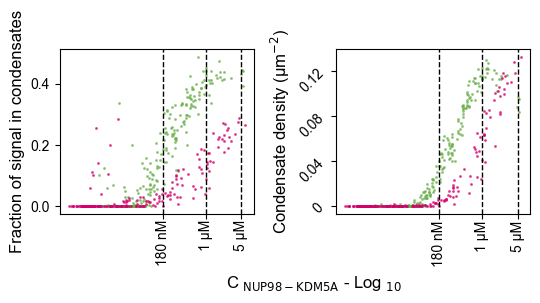

In [16]:
##Nov 29th, 2024

###Fraction of signal 
fig, ax = plt.subplots(1, 2, figsize=(5.5, 2.5))


fig.text(0.42, 0, 'C $_{\mathrm{NUP98-KDM5A}}$ - Log $_{\mathrm{10}}$', va='center', rotation='horizontal', fontsize=12, fontname="Arial")


sc1 = ax[0].scatter(np.log10(mean_cell_intensity_Nup98KDM5A_mEGFP), fraction_of_cell_signal_in_condensates_Nup98KDM5A_mEGFP,
                 marker = ".", c = Nup98_KDM5A_mEGFP_color, s = 5,
                 alpha = 0.6, label='Nup98-KDM5A-mEGFP')

# sc2 = ax[0].scatter(np.log10(mean_cell_intensity_Nup98KDM5Amut_mEGFP), fraction_of_cell_signal_in_condensates_Nup98KDM5Amut_mEGFP,
#                  marker = ".", c = Nup98_KDM5Amut_mEGFP_color, s = 5, 
#                  alpha = 0.6, label='Nup98-KDM5Amut-mEGFP')

sc3 = ax[0].scatter(np.log10(mean_cell_normalized_Nup98KDM5A_mCherry), fraction_of_cell_signal_in_condensates_Nup98KDM5A_mCherry,
                 marker = ".", c = Nup98_KDM5A_mCherry_color, s = 5,
                 alpha = 0.6, label='Nup98-KDM5A-mCherry')

# Add legend handles to the plot
#plt.legend(handles=legend_handles, loc='upper left', fontsize = 6)
#ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)

# Set the plot title and labels
#NSPARC data
#ax.set_title('Fraction of cell signal in condensates', fontsize=20, fontname="Arial")

#ax[0].set_xlabel('Mean cell intensity (au)\nLog 10', fontsize=10, fontname="Arial")
ax[0].set_ylabel('Fraction of signal in condensates', fontsize=12, fontname="Arial")

# # Set x-axis limits from 0 to 500 nM
#ax.set_xlim(0, 4)
# ax.set_ylim(0, 1)  

# plt.xticks([0, 1, 2, 3, 4])   # X-axis ticks
# plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])  # Y-axis ticks

ax[0].tick_params(axis='x', labelsize=10)
ax[0].tick_params(axis='y', labelsize=10)

# Add x calibration
xt1 = np.log10(intensity_mEGFP_180nM)
xt2 = np.log10(intensity_mEGFP_1000nM)
xt3 = np.log10(intensity_mEGFP_5000nM)
ax[0].set_xticks([xt1, xt2, xt3])
ax[0].set_xticklabels([])

ax[0].text(np.log10(intensity_mEGFP_180nM), -0.045, "180 nM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

ax[0].text(np.log10(intensity_mEGFP_1000nM), -0.045, "1 µM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

ax[0].text(np.log10(intensity_mEGFP_5000nM), -0.045, "5 µM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

# # Set y-axis limits from 0 to 1000
#ax.set_ylim(-0.00005, 0.0006)  

# Add x calibration
ax[0].axvline(x = np.log10(intensity_mEGFP_180nM), color='black', linestyle='--', linewidth=1, label='180 nM')
ax[0].axvline(x = np.log10(intensity_mEGFP_1000nM), color='black', linestyle='--', linewidth=1, label='1000 nM')
ax[0].axvline(x = np.log10(intensity_mEGFP_5000nM), color='black', linestyle='--', linewidth=1, label='5000 nM')

#######

###Density of condensates

#print(type(slope_concentration_mEGFP))

dsc1 = ax[1].scatter(np.log10(mean_cell_intensity_Nup98KDM5A_mEGFP), np.array(density_condensates_Nup98KDM5A_mEGFP) * 1/0.073,
                 marker = ".", c = Nup98_KDM5A_mEGFP_color, s = 5,
                 alpha = 0.6, label='Nup98-KDM5A-mEGFP')

# dsc2 = ax[1].scatter(np.log10(mean_cell_intensity_Nup98KDM5Amut_mEGFP), np.array(density_condensates_Nup98KDM5Amut_mEGFP) * 0.073,
#                  marker = ".", c = Nup98_KDM5Amut_mEGFP_color, s = 5,
#                  alpha = 0.6, label='Nup98-KDM5Amut-mEGFP')

dsc3 = ax[1].scatter(np.log10(mean_cell_normalized_Nup98KDM5A_mCherry), np.array(density_condensates_Nup98KDM5A_mCherry) * 1/0.073,
                 marker = ".", c = Nup98_KDM5A_mCherry_color, s = 5,
                 alpha = 0.6, label='Nup98-KDM5A-mCherry')

# Add legend handles to the plot

ax[1].set_ylabel('Condensate density (µm$^{-2}$)', fontsize=12, fontname="Arial")

ax[1].tick_params(axis='x', labelsize=10)
ax[1].tick_params(axis='y', labelsize=10)
ax[1].set_yticks([0 ,0.04, 0.08, 0.12])
ax[1].set_yticklabels([0, 0.04, 0.08, 0.12], rotation=45)
# ax[1].yaxis.set_major_formatter(
#     ticker.FuncFormatter(lambda x, _: f"{x:.0e}".replace("e-0", "e-").replace("e+0", "e+"))
# )
xt1 = np.log10(intensity_mEGFP_180nM)
xt2 = np.log10(intensity_mEGFP_1000nM)
xt3 = np.log10(intensity_mEGFP_5000nM)
ax[1].set_xticks([xt1, xt2, xt3])
ax[1].set_xticklabels([])

ax[1].text(np.log10(intensity_mEGFP_180nM), -0.013, "180 nM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

ax[1].text(np.log10(intensity_mEGFP_1000nM), -0.013, "1 µM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

ax[1].text(np.log10(intensity_mEGFP_5000nM), -0.013, "5 µM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

#Vertical lines 
# Add vertical lines
ax[1].axvline(x = np.log10(intensity_mEGFP_180nM), color='black', linestyle='--', linewidth=1, label='180 nM')
ax[1].axvline(x = np.log10(intensity_mEGFP_1000nM), color='black', linestyle='--', linewidth=1, label='1000 nM')
ax[1].axvline(x = np.log10(intensity_mEGFP_5000nM), color='black', linestyle='--', linewidth=1, label='5000 nM')

# Show the plot
#plt.grid()
fig.tight_layout()
plt.show()

# Save as PNG, 300 dpi is publication quality
image_file_name = output_path + "Fraction_and_density.png"
fig.savefig(image_file_name, bbox_inches='tight', pad_inches=0.1, dpi=300, format="png")
plt.close(fig)

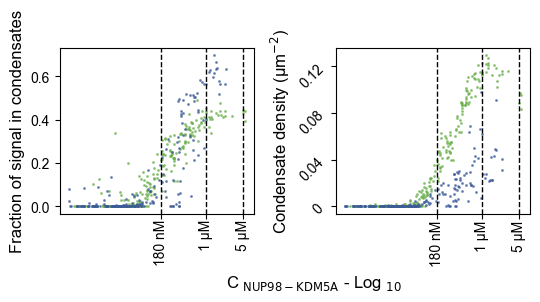

In [17]:
##Nov 29th, 2024

###Fraction of signal 
fig, ax = plt.subplots(1, 2, figsize=(5.5, 2.5))


fig.text(0.42, 0, 'C $_{\mathrm{NUP98-KDM5A}}$ - Log $_{\mathrm{10}}$', va='center', rotation='horizontal', fontsize=12, fontname="Arial")


sc1 = ax[0].scatter(np.log10(mean_cell_intensity_Nup98KDM5A_mEGFP), fraction_of_cell_signal_in_condensates_Nup98KDM5A_mEGFP,
                 marker = ".", c = Nup98_KDM5A_mEGFP_color, s = 5,
                 alpha = 0.6, label='Nup98-KDM5A-mEGFP')

sc2 = ax[0].scatter(np.log10(mean_cell_intensity_Nup98KDM5Amut_mEGFP), fraction_of_cell_signal_in_condensates_Nup98KDM5Amut_mEGFP,
                 marker = ".", c = Nup98_KDM5Amut_mEGFP_color, s = 5, 
                 alpha = 0.6, label='Nup98-KDM5Amut-mEGFP')

# sc3 = ax[0].scatter(np.log10(mean_cell_normalized_Nup98KDM5A_mCherry), fraction_of_cell_signal_in_condensates_Nup98KDM5A_mCherry,
#                  marker = ".", c = Nup98_KDM5A_mCherry_color, s = 5,
#                  alpha = 0.6, label='Nup98-KDM5A-mCherry')

# Add legend handles to the plot
#plt.legend(handles=legend_handles, loc='upper left', fontsize = 6)
#ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)

# Set the plot title and labels
#NSPARC data
#ax.set_title('Fraction of cell signal in condensates', fontsize=20, fontname="Arial")

ax[0].set_ylabel('Fraction of signal in condensates', fontsize=12, fontname="Arial")

# # Set x-axis limits from 0 to 500 nM
#ax.set_xlim(0, 4)
# ax.set_ylim(0, 1)  

# plt.xticks([0, 1, 2, 3, 4])   # X-axis ticks
# plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])  # Y-axis ticks

ax[0].tick_params(axis='x', labelsize=10)
ax[0].tick_params(axis='y', labelsize=10)

# Add x calibration
xt1 = np.log10(intensity_mEGFP_180nM)
xt2 = np.log10(intensity_mEGFP_1000nM)
xt3 = np.log10(intensity_mEGFP_5000nM)
ax[0].set_xticks([xt1, xt2, xt3])
ax[0].set_xticklabels([])

ax[0].text(np.log10(intensity_mEGFP_180nM), -0.058, "180 nM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

ax[0].text(np.log10(intensity_mEGFP_1000nM), -0.058, "1 µM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

ax[0].text(np.log10(intensity_mEGFP_5000nM), -0.058, "5 µM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

#Vertical lines 
# Add vertical lines
ax[0].axvline(x = np.log10(intensity_mEGFP_180nM), color='black', linestyle='--', linewidth=1, label='180 nM')
ax[0].axvline(x = np.log10(intensity_mEGFP_1000nM), color='black', linestyle='--', linewidth=1, label='1000 nM')
ax[0].axvline(x = np.log10(intensity_mEGFP_5000nM), color='black', linestyle='--', linewidth=1, label='5000 nM')

#######

###Density of condensates

#print(type(slope_concentration_mEGFP))

dsc1 = ax[1].scatter(np.log10(mean_cell_intensity_Nup98KDM5A_mEGFP), np.array(density_condensates_Nup98KDM5A_mEGFP) * 1/0.073,
                 marker = ".", c = Nup98_KDM5A_mEGFP_color, s = 5,
                 alpha = 0.6, label='Nup98-KDM5A-mEGFP')

dsc2 = ax[1].scatter(np.log10(mean_cell_intensity_Nup98KDM5Amut_mEGFP), np.array(density_condensates_Nup98KDM5Amut_mEGFP) * 1/0.073,
                 marker = ".", c = Nup98_KDM5Amut_mEGFP_color, s = 5,
                 alpha = 0.6, label='Nup98-KDM5Amut-mEGFP')

# dsc3 = ax[1].scatter(np.log10(mean_cell_normalized_Nup98KDM5A_mCherry), np.array(density_condensates_Nup98KDM5A_mCherry) * 1/0.073,
#                  marker = ".", c = Nup98_KDM5A_mCherry_color, s = 5,
#                  alpha = 0.6, label='Nup98-KDM5A-mCherry')

# Add legend handles to the plot
#plt.legend(handles=legend_handles, loc='upper left', fontsize = 12)
#ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)

# Set the plot title and labels
ax[1].set_ylabel('Condensate density (µm$^{-2}$)', fontsize=12, fontname="Arial")

# # Set x-axis limits from 0 to 500 nM
#ax.set_xlim(0, 4)
# ax.set_ylim(0, 0.0008)  

# plt.xticks([0, 1, 2, 3, 4])   # X-axis ticks
# plt.yticks([0, 0.0002, 0.0004, 0.0006, 0.0008])  # Y-axis ticks

ax[1].tick_params(axis='x', labelsize=10)
ax[1].tick_params(axis='y', labelsize=10)
ax[1].set_yticks([0, 0.04, 0.08, 0.12])
ax[1].set_yticklabels([0, 0.04, 0.08, 0.12], rotation=45)
# ax[1].yaxis.set_major_formatter(
#     ticker.FuncFormatter(lambda x, _: f"{x:.0e}".replace("e-0", "e-").replace("e+0", "e+"))
# )
xt1 = np.log10(intensity_mEGFP_180nM)
xt2 = np.log10(intensity_mEGFP_1000nM)
xt3 = np.log10(intensity_mEGFP_5000nM)
ax[1].set_xticks([xt1, xt2, xt3])
ax[1].set_xticklabels([])

ax[1].text(np.log10(intensity_mEGFP_180nM), -0.012, "180 nM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

ax[1].text(np.log10(intensity_mEGFP_1000nM), -0.012, "1 µM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

ax[1].text(np.log10(intensity_mEGFP_5000nM), -0.012, "5 µM", color="black", rotation=90,
        ha="center", va="top", fontsize=10, fontweight="normal")

#Vertical lines 
# Add vertical lines
ax[1].axvline(x = np.log10(intensity_mEGFP_180nM), color='black', linestyle='--', linewidth=1, label='180 nM')
ax[1].axvline(x = np.log10(intensity_mEGFP_1000nM), color='black', linestyle='--', linewidth=1, label='1000 nM')
ax[1].axvline(x = np.log10(intensity_mEGFP_5000nM), color='black', linestyle='--', linewidth=1, label='5000 nM')

# Show the plot
#plt.grid()
fig.tight_layout()
plt.show()

# Save as PNG, 300 dpi is publication quality
image_file_name = output_path + "Fraction_and_density_full.png"
fig.savefig(image_file_name, bbox_inches='tight', pad_inches=0.1, dpi=300, format="png")
plt.close(fig)